# Part 2: Baseline Regression Modeling

## Objective

The goal of this notebook is to use the engineered dataset created in Part 1 to train and evaluate multiple regression models. The performance of each model will be compared using different evaluation metrics to establish a strong baseline for predicting steel plant energy consumption.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("steel_energy_engineered.csv")

print("Dataset Loaded Successfully!\n")

print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!

Shape: (35040, 17)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_Name,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.545117,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  Hour           

## Observations

The engineered dataset was successfully loaded into the modeling notebook with **35,040 rows** and **17 columns**. It includes both the original variables and the new features created during feature engineering, such as `Hour`, `Day_of_Week_Name`, `Month`, `Day_Type`, `Power_Factor_Ratio`, and `High_Load`.

This dataset will now be used for preprocessing, encoding, and training regression models to predict energy consumption (`Usage_kWh`).

In [4]:
df = df.drop(columns=["date", "High_Load"])

print("Columns removed successfully!\n")

print("Remaining Columns:")
print(df.columns.tolist())

print("\nUpdated Dataset Shape:", df.shape)

df.head()

Columns removed successfully!

Remaining Columns:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day_of_Week_Name', 'Month', 'Day_Type', 'Power_Factor_Ratio']

Updated Dataset Shape: (35040, 15)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_Name,Month,Day_Type,Power_Factor_Ratio
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.365934
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.497679
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.422880
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.468644
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.545117


## Observations

The `date` and `High_Load` columns were successfully removed, reducing the dataset from **17** to **15** columns.

The remaining dataset contains only the features required for model training. The original `date` column was removed because its useful information was already extracted during feature engineering. The `High_Load` feature was removed to prevent **target leakage**, as it was created directly from the target variable (`Usage_kWh`).

The dataset is now prepared for the next preprocessing step, which involves encoding the categorical features.

### Remove Redundant Features

Before encoding, duplicate categorical columns are removed to avoid redundant information.

- `WeekStatus` and `Day_Type` both indicate whether a day is a weekday or weekend.
- `Day_of_week` and `Day_of_Week_Name` both represent the day of the week.

Since `Day_Type` and `Day_of_Week_Name` were created during feature engineering, they are retained, while the original duplicate columns are removed.

In [5]:
df = df.drop(columns=["WeekStatus", "Day_of_week"])

print("Duplicate columns removed successfully!\n")

print("Remaining Columns:")
print(df.columns.tolist())

print("\nUpdated Dataset Shape:", df.shape)

Duplicate columns removed successfully!

Remaining Columns:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Load_Type', 'Hour', 'Day_of_Week_Name', 'Month', 'Day_Type', 'Power_Factor_Ratio']

Updated Dataset Shape: (35040, 13)


In [6]:
df_encoded = pd.get_dummies(
    df,
    columns=["Load_Type", "Day_of_Week_Name", "Month", "Day_Type"],
    drop_first=True
)

print("One-Hot Encoding completed successfully!\n")

print("Dataset Shape:", df_encoded.shape)

df_encoded.head()

One-Hot Encoding completed successfully!

Dataset Shape: (35040, 29)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_Factor_Ratio,Load_Type_Maximum_Load,...,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Day_Type_Weekend
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,False,...,False,True,False,False,False,False,False,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,False,...,False,True,False,False,False,False,False,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,False,...,False,True,False,False,False,False,False,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,False,...,False,True,False,False,False,False,False,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,False,...,False,True,False,False,False,False,False,False,False,False


In [7]:
bool_columns = df_encoded.select_dtypes(include="bool").columns

df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

print("Boolean columns converted to integers successfully!")

df_encoded.head()

Boolean columns converted to integers successfully!


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_Factor_Ratio,Load_Type_Maximum_Load,...,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Day_Type_Weekend
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,0,...,0,1,0,0,0,0,0,0,0,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,0,...,0,1,0,0,0,0,0,0,0,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,0,...,0,1,0,0,0,0,0,0,0,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,0,...,0,1,0,0,0,0,0,0,0,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,0,...,0,1,0,0,0,0,0,0,0,0


## Observations

Duplicate categorical columns (`WeekStatus` and `Day_of_week`) were removed because the same information was already available in the engineered features (`Day_Type` and `Day_of_Week_Name`).

The remaining categorical variables were converted into numerical format using **One-Hot Encoding**. This created separate binary columns for each category, allowing the regression models to process categorical information without assuming any numerical order.

After encoding, the dataset increased from **13** to **29** columns, which is expected because each category is represented by its own binary feature.

In [8]:
X = df_encoded.drop(columns=["Usage_kWh"])

# Target variable
y = df_encoded["Usage_kWh"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (35040, 28)
Target Vector Shape  : (35040,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (28032, 28)
Testing Features  : (7008, 28)
Training Target   : (28032,)
Testing Target    : (7008,)


## Observations

The dataset was successfully divided into input features (`X`) and the target variable (`Usage_kWh`). An 80:20 train-test split was applied using `random_state=42` to ensure reproducible results.

The training dataset contains **28,032 observations**, while the testing dataset contains **7,008 observations**. The models will learn patterns from the training data and their performance will be evaluated on the unseen testing data.

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

print("Models created successfully!")

print("\nModels to be trained:")

for model in models:
    print("-", model)

Models created successfully!

Models to be trained:
- Linear Regression
- Ridge Regression
- Decision Tree
- Random Forest


In [11]:
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully!")

print("\nAll models have been trained.")

Linear Regression trained successfully!
Ridge Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!

All models have been trained.


## Observations

Four baseline regression models were successfully trained using the training dataset:

- Linear Regression
- Ridge Regression
- Decision Tree Regressor
- Random Forest Regressor

Each model learned the relationship between the input features and the target variable (`Usage_kWh`). The trained models are now ready to be evaluated on the testing dataset to compare their prediction performance.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = (mean_squared_error(y_test, y_pred)) ** 0.5
    r2 = r2_score(y_test, y_pred)

    # Store Results
    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R² Score": round(r2, 3)
    })

# Create Results Table
results_df = pd.DataFrame(results)

print("Model Evaluation Results:\n")

results_df

Model Evaluation Results:



,Model,MAE,RMSE,R² Score
0,Linear Regression,2.648,4.118,0.985
1,Ridge Regression,4.289,6.177,0.966
2,Decision Tree,0.545,1.539,0.998
3,Random Forest,0.346,1.052,0.999


## Observations

The performance of all four regression models was evaluated using MAE, RMSE, and R² Score on the testing dataset.

Among all models, the **Random Forest Regressor** achieved the best performance with the **lowest MAE (0.346)**, the **lowest RMSE (1.052)**, and the **highest R² Score (0.999)**, indicating excellent prediction accuracy.

The **Decision Tree Regressor** also performed very well with an R² Score of **0.998**, while **Linear Regression** and **Ridge Regression** produced comparatively higher prediction errors.

Overall, ensemble-based models outperformed the linear models, suggesting that the relationship between the input features and energy consumption is non-linear.

In [13]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_results = []

for name, model in models.items():

    # Negative RMSE scores returned by sklearn
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -scores.mean()

    cv_results.append({
        "Model": name,
        "Mean CV RMSE": round(rmse, 3)
    })

cv_results_df = pd.DataFrame(cv_results)

print("5-Fold Cross Validation Results:\n")

cv_results_df

5-Fold Cross Validation Results:



,Model,Mean CV RMSE
0,Linear Regression,4.567
1,Ridge Regression,6.931
2,Decision Tree,2.499
3,Random Forest,2.103


## Observations

A 5-fold cross-validation was performed to evaluate the consistency of each regression model across different subsets of the dataset.

The **Random Forest Regressor** achieved the lowest average cross-validation RMSE (**2.103**), indicating the best overall generalization performance. The **Decision Tree Regressor** ranked second with an RMSE of **2.499**, while the linear models produced higher errors.

Although the Random Forest's cross-validation RMSE is higher than its test RMSE, it still remained the best-performing model, suggesting that it generalizes well while providing highly accurate predictions.

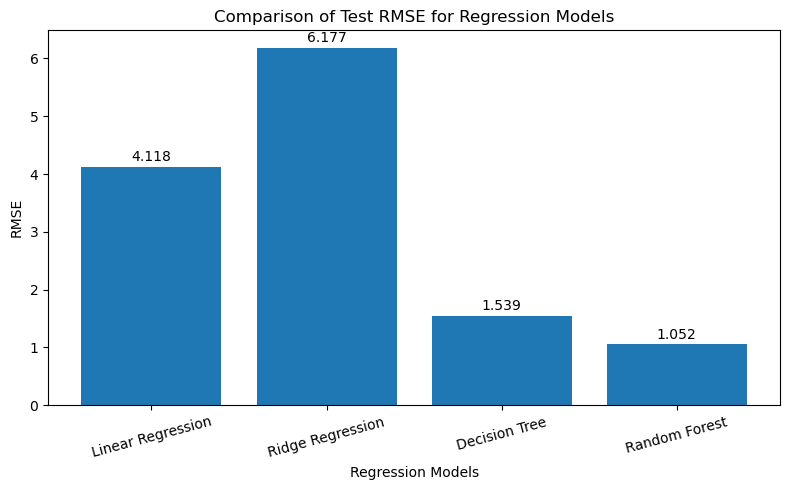

In [14]:


plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Comparison of Test RMSE for Regression Models")

plt.xlabel("Regression Models")

plt.ylabel("RMSE")

plt.xticks(rotation=15)

for index, value in enumerate(results_df["RMSE"]):
    plt.text(index, value + 0.1, str(value), ha='center')

plt.tight_layout()

plt.show()

## Observations

The RMSE comparison chart provides a clear visual comparison of all four regression models.

The **Random Forest Regressor** achieved the lowest RMSE (**1.052**), making it the most accurate model on the testing dataset. The **Decision Tree Regressor** also performed well with an RMSE of **1.539**. In contrast, **Linear Regression** and **Ridge Regression** produced higher errors, indicating that linear models were less effective at modeling the complex relationships in the dataset.

Overall, the visualization confirms that ensemble tree-based methods outperform linear regression models for predicting steel plant energy consumption.

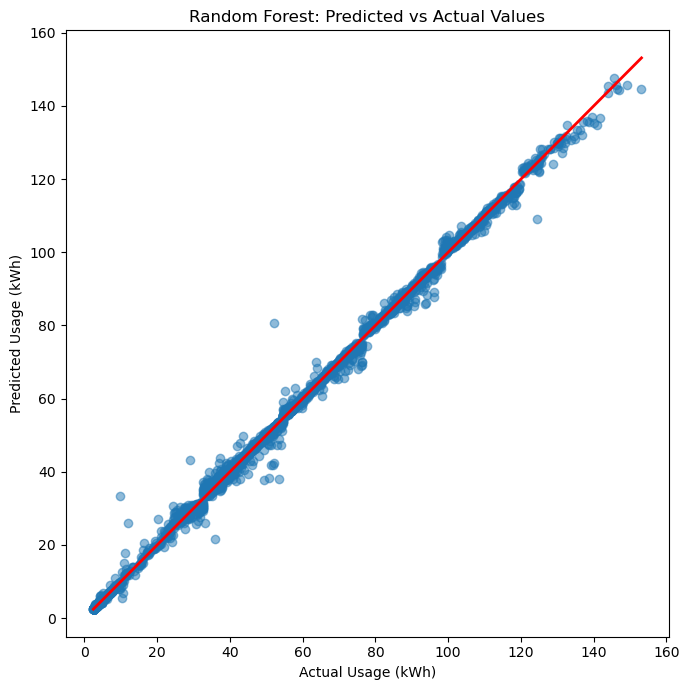

In [15]:

best_model = trained_models["Random Forest"]

y_pred = best_model.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect Prediction Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Random Forest: Predicted vs Actual Values")

plt.xlabel("Actual Usage (kWh)")

plt.ylabel("Predicted Usage (kWh)")

plt.tight_layout()

plt.show()

# Step 9: Compare Model Performance Visually

## Purpose

The performance of all baseline regression models is compared visually using their RMSE values. A lower RMSE indicates more accurate predictions, making it easier to identify the best-performing model.

## Observation

The Random Forest model achieved the lowest RMSE, followed by the Decision Tree model. Linear Regression performed reasonably well, while Ridge Regression had the highest prediction error. The visualization confirms that tree-based models captured the relationship between the features and energy consumption more effectively than the linear models.

# Step 10: Model Selection

## Model Selection Summary

Four baseline regression models were trained and evaluated using MAE, RMSE, R² Score, and 5-fold Cross Validation.

### Performance Summary

| Model | Test RMSE | Mean CV RMSE | R² Score |
|--------|----------:|-------------:|---------:|
| Linear Regression | 4.118 | 4.567 | 0.985 |
| Ridge Regression | 6.177 | 6.931 | 0.966 |
| Decision Tree | 1.539 | 2.499 | 0.998 |
| Random Forest | **1.052** | **2.103** | **0.999** |

## Best Performing Model

Random Forest achieved the best overall performance with:

- Lowest Test RMSE: **1.052**
- Lowest Mean Cross Validation RMSE: **2.103**
- Highest R² Score: **0.999**

This indicates that the model predicts energy consumption with very high accuracy while maintaining strong performance across different validation folds.

## Overfitting Analysis

The Decision Tree and Random Forest models achieved excellent prediction accuracy. Although the Random Forest's test RMSE is lower than its cross-validation RMSE, the difference is not large, suggesting good generalization rather than severe overfitting. Cross-validation confirms that the model performs consistently on unseen data.

## Selected Model

Based on both test performance and cross-validation results, **Random Forest** is selected as the final baseline model. It will be carried forward for further analysis and any future model improvement or optimization.